In [1]:
import os
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pickle
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
})

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {DEVICE}")

PyTorch version : 2.9.1
Device          : cpu


In [2]:
with open("data/processed/config.json") as f:
    config = json.load(f)

STATION_ORDER = config["station_order"]
FEAT_COLS     = config["feat_cols"]
INPUT_LEN     = config["input_len"]
HORIZON       = config["horizon"]
N             = len(STATION_ORDER)
F_DIM         = len(FEAT_COLS)

A_norm = np.load("data/processed/adj_norm.npy").astype(np.float32)
A_tensor = torch.tensor(A_norm).to(DEVICE)

X_train = np.load("data/processed/X_train.npy")
y_train = np.load("data/processed/y_train.npy")
X_val   = np.load("data/processed/X_val.npy")
y_val   = np.load("data/processed/y_val.npy")
X_test  = np.load("data/processed/X_test.npy")
y_test  = np.load("data/processed/y_test.npy")

print(f"N stations  : {N}")
print(f"N features  : {F_DIM}")
print(f"Input len   : {INPUT_LEN}")
print(f"Horizon     : {HORIZON}")
print(f"A_norm      : {A_norm.shape}")
print()
print(f"X_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape}   y_val   : {y_val.shape}")
print(f"X_test  : {X_test.shape}   y_test  : {y_test.shape}")

N stations  : 10
N features  : 10
Input len   : 14
Horizon     : 7
A_norm      : (10, 10)

X_train : (2773, 14, 10, 10)   y_train : (2773, 7, 10)
X_val   : (316, 14, 10, 10)   y_val   : (316, 7, 10)
X_test  : (674, 14, 10, 10)   y_test  : (674, 7, 10)


In [3]:
class DischargeDataset(Dataset):
    """
    Wraps X (samples, input_len, N, F) and y (samples, horizon, N)
    as a PyTorch Dataset.
    """
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


BATCH_SIZE = 32

train_ds = DischargeDataset(X_train, y_train)
val_ds   = DischargeDataset(X_val,   y_val)
test_ds  = DischargeDataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

# Verify one batch
xb, yb = next(iter(train_loader))
print(f"\nBatch X : {xb.shape}   (batch, input_len, N, F)")
print(f"Batch y : {yb.shape}   (batch, horizon, N)")

Train batches : 86
Val batches   : 10
Test batches  : 22

Batch X : torch.Size([32, 14, 10, 10])   (batch, input_len, N, F)
Batch y : torch.Size([32, 7, 10])   (batch, horizon, N)


In [4]:
class GCNLayer(nn.Module):
    """
    Single graph convolution layer.
    H_out = A_norm @ H_in @ W   (+ optional bias)

    A_norm : (N, N)  pre-computed normalised adjacency (fixed, not learned)
    in_dim  : input feature dimension per node
    out_dim : output feature dimension per node
    """
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.W = nn.Linear(in_dim, out_dim, bias=True)

    def forward(self, H, A):
        """
        H : (batch, N, in_dim)
        A : (N, N)
        returns : (batch, N, out_dim)
        """
        # Message passing: aggregate neighbour features
        AH = torch.matmul(A, H)          # (batch, N, in_dim)
        return F.relu(self.W(AH))        # (batch, N, out_dim)

In [5]:
class STGNN(nn.Module):
    """
    Spatiotemporal GNN for multi-step, multi-site discharge forecasting.

    Architecture
    ------------
    1. Temporal encoder  : GRU applied independently per node
                           Input  (batch, input_len, N, F)
                           Output (batch, N, hidden_dim)

    2. Graph conv layer  : GCN propagates upstream signals to downstream nodes
                           Input  (batch, N, hidden_dim)
                           Output (batch, N, gcn_dim)

    3. Decoder           : Linear projection to horizon steps per node
                           Input  (batch, N, gcn_dim)
                           Output (batch, horizon, N)
    """
    def __init__(self, f_dim, hidden_dim, gcn_dim, horizon, n_nodes,
                 n_gru_layers=1, dropout=0.1, use_graph=True):
        super().__init__()
        self.n_nodes    = n_nodes
        self.horizon    = horizon
        self.use_graph  = use_graph

        # --- Temporal encoder (shared weights across nodes) ---
        self.gru = nn.GRU(
            input_size  = f_dim,
            hidden_size = hidden_dim,
            num_layers  = n_gru_layers,
            batch_first = True,
            dropout     = dropout if n_gru_layers > 1 else 0.0,
        )

        # --- Graph convolution ---
        self.gcn = GCNLayer(hidden_dim, gcn_dim)

        # --- Decoder ---
        self.dropout = nn.Dropout(dropout)
        self.decoder = nn.Linear(gcn_dim, horizon)

    def forward(self, X, A):
        """
        X : (batch, input_len, N, F)
        A : (N, N)
        returns : (batch, horizon, N)
        """
        batch, T, N_nodes, F_dim = X.shape   # renamed to avoid collision with F module

        # --- Step 1: Temporal encoding ---
        # Reshape to process all nodes independently through same GRU
        # (batch * N, input_len, F)
        X_reshaped = X.permute(0, 2, 1, 3).reshape(batch * N_nodes, T, F_dim)
        _, h_n = self.gru(X_reshaped)        # h_n: (n_layers, batch*N, hidden)
        h = h_n[-1]                           # (batch*N, hidden_dim)
        H = h.reshape(batch, N_nodes, -1)     # (batch, N, hidden_dim)

        # --- Step 2: Graph convolution ---
        if self.use_graph:
            H = self.gcn(H, A)               # (batch, N, gcn_dim)
        else:
            # No-graph ablation: skip message passing, apply projection only
            H = torch.relu(self.gcn.W(H))    # (batch, N, gcn_dim)

        # --- Step 3: Decode ---
        H = self.dropout(H)
        out = self.decoder(H)                # (batch, N, horizon)
        out = out.permute(0, 2, 1)           # (batch, horizon, N)
        return out

In [6]:
class PersistenceBaseline:
    """
    Naive baseline: forecast = last observed discharge repeated H times.
    For each sample, uses X[:, -1, :, 0] (last day, all nodes, discharge col).
    """
    def predict(self, X):
        # X: (samples, input_len, N, F)
        last = X[:, -1, :, 0]          # (samples, N)  — discharge is col 0
        pred = np.stack([last] * HORIZON, axis=1)  # (samples, horizon, N)
        return pred


class ClimatologyBaseline:
    """
    Seasonal baseline: for each day-of-year, predict the training mean.
    Fitted on y_train targets (scaled log discharge).
    """
    def fit(self, y_train, dates_train):
        """
        y_train   : (samples, horizon, N)
        dates_train: list of forecast-start dates, length = samples
        """
        self.doy_mean = {}
        for i, date in enumerate(dates_train):
            for h in range(HORIZON):
                # actual forecast date for horizon step h
                import datetime
                fdate = date + datetime.timedelta(days=h)
                doy = fdate.timetuple().tm_yday
                if doy not in self.doy_mean:
                    self.doy_mean[doy] = []
                self.doy_mean[doy].append(y_train[i, h, :])  # (N,)

        # Average per DOY
        self.doy_mean = {
            doy: np.mean(np.stack(vals), axis=0)
            for doy, vals in self.doy_mean.items()
        }
        # Global mean as fallback
        all_vals = np.concatenate([v for v in self.doy_mean.values()], axis=0)
        self.global_mean = all_vals.mean(axis=0) if all_vals.ndim > 1 else all_vals

    def predict(self, dates_test):
        import datetime
        preds = []
        for date in dates_test:
            horizon_pred = []
            for h in range(HORIZON):
                fdate = date + datetime.timedelta(days=h)
                doy = fdate.timetuple().tm_yday
                horizon_pred.append(self.doy_mean.get(doy, self.global_mean))
            preds.append(np.stack(horizon_pred))   # (horizon, N)
        return np.stack(preds)                      # (samples, horizon, N)

In [7]:
# Hyperparameters
HIDDEN_DIM  = 64
GCN_DIM     = 64
N_GRU_LAYERS = 2
DROPOUT     = 0.1

# Full STGNN (with graph)
model_stgnn = STGNN(
    f_dim       = F_DIM,
    hidden_dim  = HIDDEN_DIM,
    gcn_dim     = GCN_DIM,
    horizon     = HORIZON,
    n_nodes     = N,
    n_gru_layers= N_GRU_LAYERS,
    dropout     = DROPOUT,
    use_graph   = True,
).to(DEVICE)

# No-graph ablation (identity adjacency skipped)
model_nograph = STGNN(
    f_dim       = F_DIM,
    hidden_dim  = HIDDEN_DIM,
    gcn_dim     = GCN_DIM,
    horizon     = HORIZON,
    n_nodes     = N,
    n_gru_layers= N_GRU_LAYERS,
    dropout     = DROPOUT,
    use_graph   = False,
).to(DEVICE)

# Forward pass sanity check
xb_dev = xb.to(DEVICE)
with torch.no_grad():
    out_stgnn   = model_stgnn(xb_dev, A_tensor)
    out_nograph = model_nograph(xb_dev, A_tensor)

print("=== Forward pass OK ===")
print(f"Input  shape : {xb_dev.shape}")
print(f"STGNN output : {out_stgnn.shape}     expected (batch, {HORIZON}, {N})")
print(f"NoGraph out  : {out_nograph.shape}")

=== Forward pass OK ===
Input  shape : torch.Size([32, 14, 10, 10])
STGNN output : torch.Size([32, 7, 10])     expected (batch, 7, 10)
NoGraph out  : torch.Size([32, 7, 10])


In [8]:
def count_params(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

total, trainable = count_params(model_stgnn)
print(f"STGNN total params     : {total:,}")
print(f"STGNN trainable params : {trainable:,}")
print()

# Layer-by-layer breakdown
print("Layer breakdown:")
for name, param in model_stgnn.named_parameters():
    print(f"  {name:35s}  {str(tuple(param.shape)):25s}  {param.numel():,}")

STGNN total params     : 44,167
STGNN trainable params : 44,167

Layer breakdown:
  gru.weight_ih_l0                     (192, 10)                  1,920
  gru.weight_hh_l0                     (192, 64)                  12,288
  gru.bias_ih_l0                       (192,)                     192
  gru.bias_hh_l0                       (192,)                     192
  gru.weight_ih_l1                     (192, 64)                  12,288
  gru.weight_hh_l1                     (192, 64)                  12,288
  gru.bias_ih_l1                       (192,)                     192
  gru.bias_hh_l1                       (192,)                     192
  gcn.W.weight                         (64, 64)                   4,096
  gcn.W.bias                           (64,)                      64
  decoder.weight                       (7, 64)                    448
  decoder.bias                         (7,)                       7


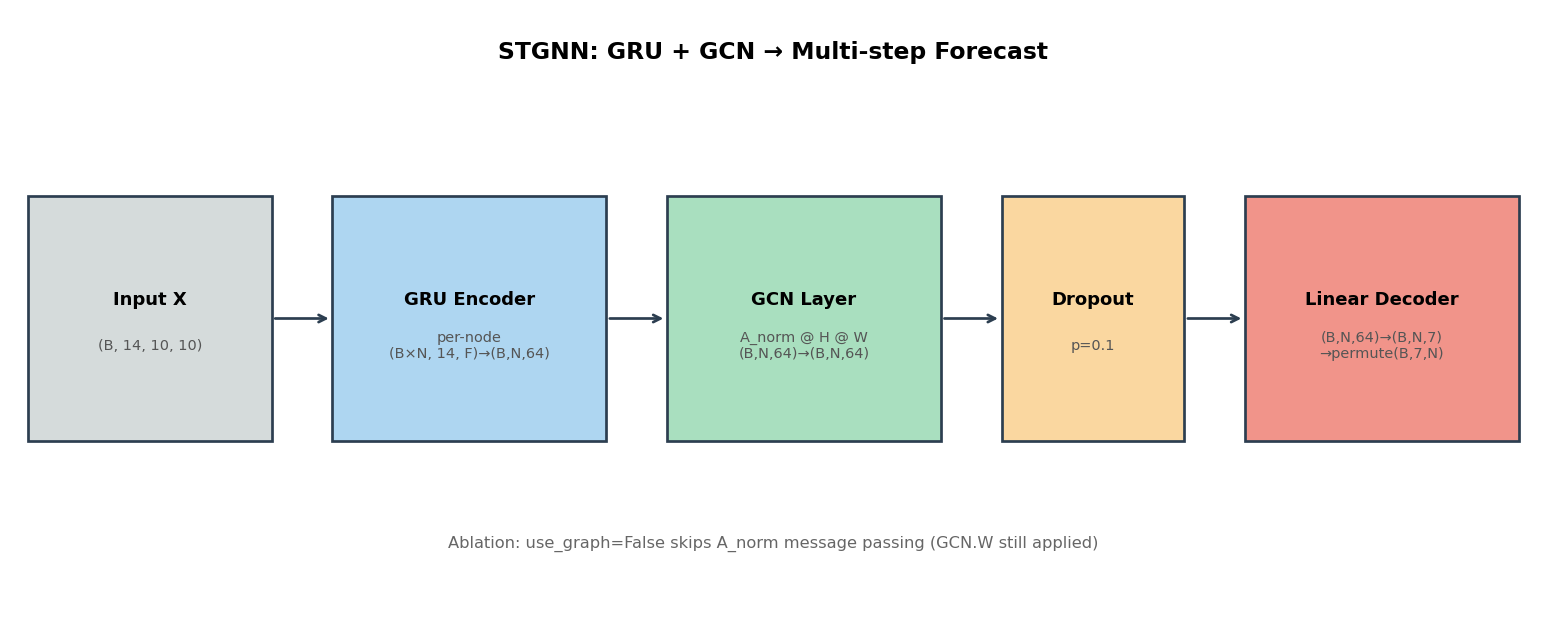

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 4)
ax.axis("off")

def draw_box(ax, x, y, w, h, label, sublabel="", color="#AED6F1"):
    rect = plt.Rectangle((x, y), w, h,
                          facecolor=color, edgecolor="#2C3E50", linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2 + 0.12, label,
            ha="center", va="center", fontsize=10, fontweight="bold")
    if sublabel:
        ax.text(x + w/2, y + h/2 - 0.18, sublabel,
                ha="center", va="center", fontsize=8, color="#555")

def draw_arrow(ax, x1, x2, y=2.0):
    ax.annotate("", xy=(x2, y), xytext=(x1, y),
                arrowprops=dict(arrowstyle="->", color="#2C3E50", lw=1.5))

# Input
draw_box(ax, 0.1, 1.2, 1.6, 1.6, "Input X",
         "(B, 14, 10, 10)", color="#D5DBDB")
draw_arrow(ax, 1.7, 2.1)

# GRU
draw_box(ax, 2.1, 1.2, 1.8, 1.6, "GRU Encoder",
         "per-node\n(B×N, 14, F)→(B,N,64)", color="#AED6F1")
draw_arrow(ax, 3.9, 4.3)

# GCN
draw_box(ax, 4.3, 1.2, 1.8, 1.6, "GCN Layer",
         "A_norm @ H @ W\n(B,N,64)→(B,N,64)", color="#A9DFBF")
draw_arrow(ax, 6.1, 6.5)

# Dropout
draw_box(ax, 6.5, 1.2, 1.2, 1.6, "Dropout",
         f"p={DROPOUT}", color="#FAD7A0")
draw_arrow(ax, 7.7, 8.1)

# Decoder
draw_box(ax, 8.1, 1.2, 1.8, 1.6, "Linear Decoder",
         "(B,N,64)→(B,N,7)\n→permute(B,7,N)", color="#F1948A")

# Labels
ax.text(5.0, 3.7, "STGNN: GRU + GCN → Multi-step Forecast",
        ha="center", fontsize=13, fontweight="bold")
ax.text(5.0, 0.5,
        "Ablation: use_graph=False skips A_norm message passing (GCN.W still applied)",
        ha="center", fontsize=9, color="#666")

plt.tight_layout()
plt.show()

In [10]:
def masked_mse(pred, target):
    """
    MSE loss ignoring NaN positions in target.
    In practice targets are clean after window-drop,
    but this guard makes training robust.
    """
    mask = ~torch.isnan(target)
    return F.mse_loss(pred[mask], target[mask])


def make_optimizer(model, lr=1e-3, weight_decay=1e-4):
    return torch.optim.Adam(model.parameters(),
                            lr=lr, weight_decay=weight_decay)


# Confirm loss runs on one batch
pred_test = model_stgnn(xb.to(DEVICE), A_tensor)
loss_test  = masked_mse(pred_test, yb.to(DEVICE))

print(f"Loss function : masked MSE")
print(f"Test loss on one batch : {loss_test.item():.4f}")
print(f"Optimizer     : Adam  lr=1e-3  weight_decay=1e-4")

Loss function : masked MSE
Test loss on one batch : 0.1280
Optimizer     : Adam  lr=1e-3  weight_decay=1e-4
